In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

from pgmpy.base import DAG
from pgmpy.factors.discrete.CPD import TabularCPD
from pgmpy.models import DiscreteBayesianNetwork as bn
from pgmpy.inference import VariableElimination as Inference

# Build the causal DAG.
model = bn()
model.add_edges_from(
    [
      ('A','E'),
      ('S','E'),
      ('E','O'),
      ('E','R'),
      ('O','T'),
      ('R','T')
    ]
)

I will you graphviz rather then install yet another dependency (Daft!).

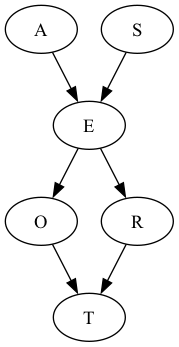

In [32]:
from IPython.display import Image
model.to_graphviz().draw("week4dag1.png", prog="dot")
Image("week4dag1.png")

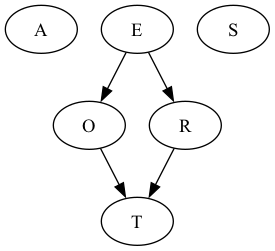

In [33]:
 
mutilated_model = model.do("E")
mutilated_model.to_graphviz().draw("week4dag2.png", prog="dot")
Image("week4dag2.png")

In [36]:
survey_url = "https://raw.githubusercontent.com/altdeep/causalML/master/datasets/transportation_survey.csv"
data = pd.read_csv(survey_url)
model.fit(data)
mutilated_model.fit(data)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'C', 'S': 'C', 'E': 'C', 'O': 'C', 'R': 'C', 'T': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'A': 'C', 'S': 'C', 'E': 'C', 'O': 'C', 'R': 'C', 'T': 'C'}


Is this right? I thought we would be training the un-mutilated model and then mutilating it for inference ? I think it is ok since all the downstream nodes will still just refit the same way.

In [37]:
print(mutilated_model.get_cpds('E'))

+---------+------+
| E(high) | 0.58 |
+---------+------+
| E(uni)  | 0.42 |
+---------+------+


There is supposed to be a problem here? Well shouldnt this be whatever we want to intervene E to be ?  So lets set it to be 1.0 for "uni" . 

In [38]:
mutilated_model.add_cpds(TabularCPD('E', variable_card=2, values = [[0.0], [1.0]], state_names={'E': ['high', 'uni']}))

In [39]:
print(mutilated_model.get_cpds('E'))

+---------+---+
| E(high) | 0 |
+---------+---+
| E(uni)  | 1 |
+---------+---+


In [40]:
inference = Inference(model)
intervention_inference = Inference(mutilated_model)
print("P(S|E='uni'):")
print(inference.query(variables=['S'], evidence={'E': "uni"}))
print("\n")
print("P(S|do(E='uni')):")
print(intervention_inference.query(variables=['S'], evidence={'E': "uni"}))

P(S|E='uni'):
+------+----------+
| S    |   phi(S) |
+======+==========+
| S(F) |   0.7584 |
+------+----------+
| S(M) |   0.2416 |
+------+----------+


P(S|do(E='uni')):
+------+----------+
| S    |   phi(S) |
+======+==========+
| S(F) |   0.5220 |
+------+----------+
| S(M) |   0.4780 |
+------+----------+


## Part 2

For DAG 5 in the assessment, we are asked to comptue P(Y | do(X)) given a confounder Z.  THe backdoor adjustment formula is given as:


P(Y | do(X)) = Σ_z P(Y | X, Z) P(Z)

So we need to compute P(Y | X, Z) and P(Z) from the data.   We can do this by hand....   

In [49]:
P_X0_Z_Unhappy = 8173/8769
P_X0_Z_Happy = 19228/26231
P_X1_Z_Unhappy = 23339/26872
P_X1_Z_Happy = 5582/8128

P_Z_Unhappy = (8769+26872)/70000
P_Z_Happy = (26231+ 8128)/70000

P_Y_do_X0 = P_X0_Z_Unhappy * P_Z_Unhappy + P_X0_Z_Happy * P_Z_Happy
P_Y_do_X1 = P_X1_Z_Unhappy * P_Z_Unhappy + P_X1_Z_Happy * P_Z_Happy

# compute differnece
ATE = P_Y_do_X1 - P_Y_do_X0
print(ATE)

-0.05504412915580603


Now lets do this with Pyro... TBD

In [41]:
import torch
import pyro
import pyro.distributions as dist

Z_alias = {'unhappy', 'happy'}
X_alias = {'promotion0', 'promotion1'}
Y_alias = {'norenew', 'renew'}

N = 70000
N_happy_promo0 = 26231
N_happy_promo1 = 8128
N_unhappy_promo0 = 8769
N_unhappy_promo1 = 26872
N_happy = N_happy_promo0 + N_happy_promo1
N_unhappy = N_unhappy_promo0 + N_unhappy_promo1

# P(Z=unhappy), P(Z=happy)
prob_Z = torch.tensor([N_unhappy/N, N_happy/N])

# P(X=promo0 |Z= unhappy), P(X=promo1 |Z= unhappy)
# P(X=promo0 |Z= happy), P(X=promo1 |Z= happy)
prob_X = torch.tensor([
    [N_unhappy_promo0/N_unhappy, N_unhappy_promo1/N_unhappy],
    [N_happy_promo0/N_happy, N_happy_promo1/N_happy]
])  

# P(Y=norenew | X=promo0, Z=unhappy), P(Y=renew | X=promo0, Z=unhappy)
# P(Y=norenew | X=promo0, Z=happy), P(Y=renew | X=promo0, Z=happy)
    
# P(Y=norenew | X=promo1, Z=unhappy), P(Y=renew | X=promo1, Z=unhappy)
# P(Y=norenew | X=promo1, Z=happy), P(Y=renew | X=promo1, Z=happy)
prob_Y = torch.tensor([
    [
        [0.068, 0.932],
        [0.267, 0.733]
    ],
    [
        [0.131, 0.869],
        [0.313, 0.687]
    ]
])  # P(Y|X,Z)
 
def promo_model():
    Z = pyro.sample('Z', dist.Categorical(probs=prob_Z))
    X = pyro.sample('X', dist.Categorical(probs=prob_X[Z]))
    Y = pyro.sample('Y', dist.Categorical(probs=prob_Y[X][Z]))
    return {'Z': Z, 'X': X, 'Y': Y}

### Dag 6 

Data is avaiable in the file `social_media_advertisements.csv` in the datasets directory of the repo.  

In [2]:
social_media_data = pd.read_csv('../datasets/social_media_advertisements.csv')
social_media_data

,Z,X,Y
0,no_ad,no_social,purchase
1,no_ad,no_social,purchase
2,ad,social,no_purchase
3,ad,social,no_purchase
4,no_ad,no_social,purchase
...,...,...,...
795,no_ad,no_social,purchase
796,ad,social,no_purchase
797,ad,social,no_purchase
798,no_ad,social,no_purchase


Ok this is a frontdoor adjustment... the formula using the mediator Z is:


P(Y | do(X)) = Σ_z P(Z | X) Σ_x' P(Y | x', Z) P(x')

In [28]:
# probabilities from data

P_x = social_media_data['X'].value_counts(normalize=True)
# This turns out to be 0.5 for both x=0 and x=1

#Probability of Y given x and z. Here we just enumerate the possibilities. Probably a better way :) 
def P_purchase_given_xz(x, z):
    return social_media_data[(social_media_data['X']==x) & (social_media_data['Z']==z)]['Y'].value_counts(normalize=True)['purchase']

# Probability of 'ad' and 'no ad' given social media
 
def P_ad_given_x(x):
    return social_media_data[social_media_data['X']==x]['Z'].value_counts(normalize=True)

# this is super klunky ... rework it.
def P_purchase_do_X(x):
    p = 0
    for z in ['ad', 'no_ad']:
        p_z = P_ad_given_x(x)[z]
        for x_prime in ['social', 'no_social']:
            p_y_given_xz = P_purchase_given_xz(x_prime, z)
            p += p_y_given_xz * p_z * P_x[x_prime]
    return p

P_purchase_do_X('social')- P_purchase_do_X('no_social')

np.float64(0.04499999999999993)

NO idea why i dont get the same answer as in the assessment...

check aggregated data

In [34]:
agg_df = social_media_data.groupby(["X", "Z", "Y"]).size().reset_index()

In [36]:
agg_df

,X,Z,Y,0
0,no_social,ad,no_purchase,1
1,no_social,ad,purchase,19
2,no_social,no_ad,no_purchase,38
3,no_social,no_ad,purchase,342
4,social,ad,no_purchase,323
5,social,ad,purchase,57
6,social,no_ad,no_purchase,18
7,social,no_ad,purchase,2
